# Hospital Readmission - Baseline Modeling

**Author:** Mujtaba Alsabari  
**Notebook:** 03_modeling  
**Goal:** Train and evaluate baseline classification models to predict 30-day hospital readmission, establishing a benchmark for more advanced models.

## Models compared
1. **Logistic Regression** — interpretable linear baseline
2. **Random Forest** — captures nonlinear patterns and interactions

## Evaluation metrics
- **AUC-ROC** (primary) — handles class imbalance well
- **Precision** — when we predict readmit, how often are we right?
- **Recall** — of all true readmits, how many do we catch?
- **F1-score** — balance of precision and recall
- **Confusion matrix** — visual error analysis

## Methodology
- Stratified 80/20 train/test split (preserves class proportions)
- Class weighting to handle ~7.5% positive class imbalance (first-encounter-per-patient rate after deduplication)
- No data leakage: all preprocessing fit on train, applied to test

In [44]:
# Standard data science stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
import xgboost as xgb
import joblib
import os

# Scikit-learn — the workhorse ML library in Python
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

# Display settings
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# For reproducibility
RANDOM_STATE = 42

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load the processed dataset from Phase 3
df = pd.read_csv('../data/processed/cleaned.csv')

print(f"Loaded cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Quick verification — should match Phase 3 output
print(f"\nTarget distribution:")
print(df['readmitted_30d'].value_counts())
print(f"\nPositive class rate: {df['readmitted_30d'].mean()*100:.2f}%")

Loaded cleaned dataset: 68,750 rows × 133 columns
Memory usage: 69.8 MB

Target distribution:
readmitted_30d
0    63614
1     5136
Name: count, dtype: int64

Positive class rate: 7.47%


In [3]:
# Separate features (X) from target (y)
# We do NOT reassign df — keep the full dataframe intact for later inspection.
y = df['readmitted_30d']
X = df.drop(columns=['readmitted_30d'])

# Verify the separation
print(f"X shape (features): {X.shape}")
print(f"y shape (target):   {y.shape}")
print(f"\nFirst few values of y:")
print(y.head())

X shape (features): (68750, 132)
y shape (target):   (68750,)

First few values of y:
0    1
1    0
2    0
3    0
4    0
Name: readmitted_30d, dtype: int64


In [4]:
# Split into training and test sets — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,           # 20% of data goes to test
    stratify=y,               # preserve class proportions in both splits
    random_state=RANDOM_STATE  # reproducibility
)

# Verify shapes and class balance
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

print(f"\nTraining positive class rate: {y_train.mean()*100:.2f}%")
print(f"Test positive class rate:     {y_test.mean()*100:.2f}%")
print(f"Original positive class rate: {y.mean()*100:.2f}%")

X_train shape: (55000, 132)
X_test shape:  (13750, 132)
y_train shape: (55000,)
y_test shape:  (13750,)

Training positive class rate: 7.47%
Test positive class rate:     7.47%
Original positive class rate: 7.47%


In [11]:
# Scale features to mean=0, std=1 (Logistic Regression is sensitive to feature scale)
# IMPORTANT: fit scaler on TRAIN only, apply to both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape:  {X_test_scaled.shape}")
print(f"\nMean of scaled features (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Std of scaled features  (should be ~1): {X_train_scaled.std():.4f}")

# Train Logistic Regression on SCALED data (n_jobs removed — deprecated)
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

print("Training Logistic Regression on scaled data...")
log_reg.fit(X_train_scaled, y_train)
print("✅ Training complete (no convergence warning expected)")

Scaled X_train shape: (55000, 132)
Scaled X_test shape:  (13750, 132)

Mean of scaled features (should be ~0): 0.0000
Std of scaled features  (should be ~1): 0.9847
Training Logistic Regression on scaled data...
✅ Training complete (no convergence warning expected)


In [12]:
# Generate two kinds of predictions on the test set
y_pred = log_reg.predict(X_test_scaled)              # hard 0/1 predictions
y_pred_proba = log_reg.predict_proba(X_test_scaled)  # probabilities for each class

# Inspect what we got back
print(f"y_pred shape: {y_pred.shape}")
print(f"First 10 hard predictions: {y_pred[:10]}")

print(f"\ny_pred_proba shape: {y_pred_proba.shape}")
print(f"First 5 probability predictions:")
print(y_pred_proba[:5])

# Extract just the probability of the POSITIVE class (column index 1)
# This is what we'll use for AUC-ROC.
y_pred_proba_pos = y_pred_proba[:, 1]
print(f"\nFirst 10 probabilities of positive class: {y_pred_proba_pos[:10].round(3)}")

y_pred shape: (13750,)
First 10 hard predictions: [1 0 0 1 0 1 0 0 1 0]

y_pred_proba shape: (13750, 2)
First 5 probability predictions:
[[0.45828786 0.54171214]
 [0.71341847 0.28658153]
 [0.7651348  0.2348652 ]
 [0.45856972 0.54143028]
 [0.68217524 0.31782476]]

First 10 probabilities of positive class: [0.542 0.287 0.235 0.541 0.318 0.589 0.41  0.373 0.541 0.287]


In [13]:
# Comprehensive evaluation of the Logistic Regression baseline
print("=" * 60)
print("LOGISTIC REGRESSION — TEST SET PERFORMANCE")
print("=" * 60)

# Standard metrics — using hard predictions
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# AUC — uses probability predictions, not hard predictions
auc = roc_auc_score(y_test, y_pred_proba_pos)

print(f"Accuracy:  {acc:.4f}   (% correct overall)")
print(f"Precision: {prec:.4f}   (when predicting readmit, % correct)")
print(f"Recall:    {rec:.4f}   (% of true readmits caught)")
print(f"F1 Score:  {f1:.4f}   (harmonic mean of precision & recall)")
print(f"AUC-ROC:   {auc:.4f}   (ranking quality, threshold-free)")

# Save baseline results for later comparison
baseline_results = {
    'model': 'Logistic Regression',
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'auc': auc,
}

LOGISTIC REGRESSION — TEST SET PERFORMANCE
Accuracy:  0.6833   (% correct overall)
Precision: 0.1279   (when predicting readmit, % correct)
Recall:    0.5570   (% of true readmits caught)
F1 Score:  0.2081   (harmonic mean of precision & recall)
AUC-ROC:   0.6704   (ranking quality, threshold-free)


Confusion Matrix (Logistic Regression):

                 Predicted: 0    Predicted: 1
Actual: 0   ┃      8,824               3,899
Actual: 1   ┃        455                 572

 Test set breakdown (13,750 patients):
   True Negatives  (correctly predicted NO readmit):  8,824
   False Positives (false alarms):                    3,899
   False Negatives (MISSED readmissions):               455
   True Positives  (correctly predicted readmit):       572


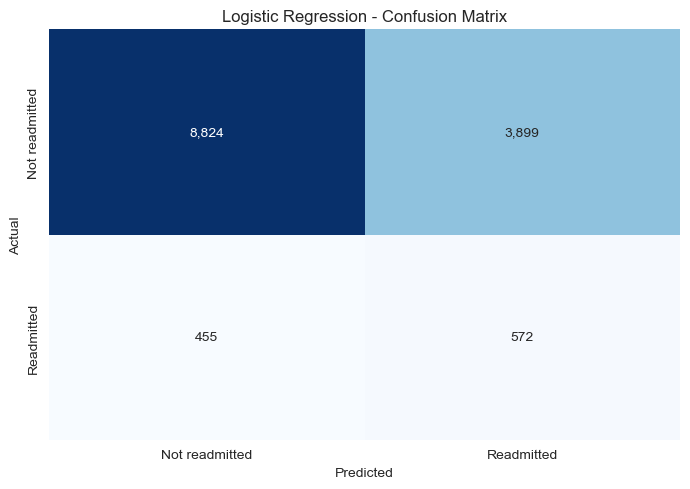

In [27]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Pretty print
print("Confusion Matrix (Logistic Regression):")
print()
print(f"                 Predicted: 0    Predicted: 1")
print(f"Actual: 0   ┃     {cm[0,0]:>6,}              {cm[0,1]:>6,}")
print(f"Actual: 1   ┃     {cm[1,0]:>6,}              {cm[1,1]:>6,}")

# Calculate the four key counts
tn, fp, fn, tp = cm.ravel()
total = len(y_test)

print(f"\n Test set breakdown ({total:,} patients):")
print(f"   True Negatives  (correctly predicted NO readmit): {tn:>6,}")
print(f"   False Positives (false alarms):                   {fp:>6,}")
print(f"   False Negatives (MISSED readmissions):            {fn:>6,}")
print(f"   True Positives  (correctly predicted readmit):    {tp:>6,}")

# Visual heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Not readmitted', 'Readmitted'],
            yticklabels=['Not readmitted', 'Readmitted'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [28]:
# Train Random Forest classifier on UNSCALED data
# (trees don't care about feature scale)
rf = RandomForestClassifier(
    n_estimators=100,         # number of trees in the forest
    max_depth=None,           # let trees grow fully (no depth limit)
    min_samples_split=20,     # need at least 20 samples to split a node (prevents overfitting)
    class_weight='balanced',  # handle 92.5/7.5 class imbalance
    n_jobs=-1,                # use all CPU cores (RF supports this)
    random_state=RANDOM_STATE
)

print("Training Random Forest (this will take a minute)...")
rf.fit(X_train, y_train)
print("Training complete")

Training Random Forest (this will take a minute)...
Training complete


In [29]:
# Generate predictions on the test set (using unscaled X_test)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Compute all metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("=" * 60)
print("RANDOM FOREST — TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print(f"AUC-ROC:   {auc_rf:.4f}")

# Save for comparison
rf_results = {
    'model': 'Random Forest',
    'accuracy': acc_rf,
    'precision': prec_rf,
    'recall': rec_rf,
    'f1': f1_rf,
    'auc': auc_rf,
}

RANDOM FOREST — TEST SET PERFORMANCE
Accuracy:  0.9193
Precision: 0.2670
Recall:    0.0458
F1 Score:  0.0781
AUC-ROC:   0.6602


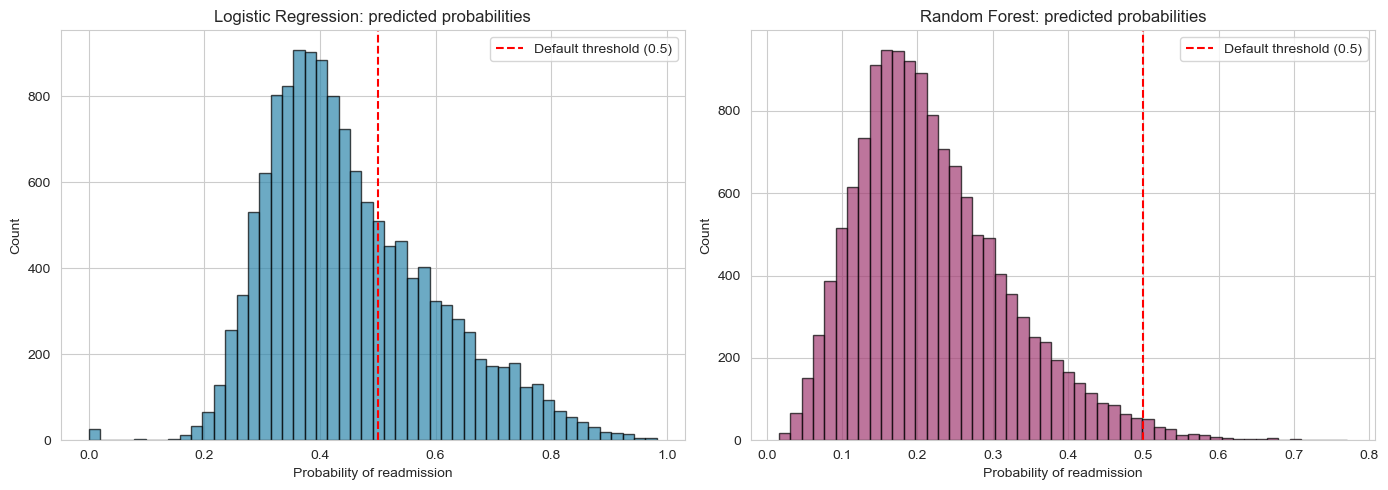

Logistic Regression: mean prob = 0.455, max = 0.982
Random Forest:       mean prob = 0.221, max = 0.770

RF probabilities above 0.5: 176 of 13,750 (1.3%)


In [30]:
# Diagnostic: distribution of RF predicted probabilities
import matplotlib.pyplot as plt

# Compare probability distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_pred_proba_pos, bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0].axvline(0.5, color='red', linestyle='--', label='Default threshold (0.5)')
axes[0].set_title('Logistic Regression: predicted probabilities')
axes[0].set_xlabel('Probability of readmission')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(y_pred_proba_rf, bins=50, color='#A23B72', edgecolor='black', alpha=0.7)
axes[1].axvline(0.5, color='red', linestyle='--', label='Default threshold (0.5)')
axes[1].set_title('Random Forest: predicted probabilities')
axes[1].set_xlabel('Probability of readmission')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Logistic Regression: mean prob = {y_pred_proba_pos.mean():.3f}, max = {y_pred_proba_pos.max():.3f}")
print(f"Random Forest:       mean prob = {y_pred_proba_rf.mean():.3f}, max = {y_pred_proba_rf.max():.3f}")
print(f"\nRF probabilities above 0.5: {(y_pred_proba_rf > 0.5).sum():,} of {len(y_pred_proba_rf):,} ({(y_pred_proba_rf > 0.5).mean()*100:.1f}%)")

In [31]:
# Retrain RF with stronger class balancing
rf = RandomForestClassifier(
    n_estimators=200,                  # more trees for stability
    max_depth=15,                      # cap depth — limits overfit, encourages cleaner splits
    min_samples_split=20,
    min_samples_leaf=10,               # require 10+ samples in each leaf
    class_weight='balanced_subsample', # STRONGER than 'balanced' for RF specifically
    n_jobs=-1,
    random_state=RANDOM_STATE
)

print("Training Random Forest with stronger settings...")
rf.fit(X_train, y_train)
print("Training complete")

Training Random Forest with stronger settings...
Training complete


In [32]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Evaluation at default threshold (0.5)
print("=" * 60)
print("RANDOM FOREST — DEFAULT THRESHOLD (0.5)")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

# Evaluation at a tuned threshold (e.g., 0.30 — favors recall)
threshold = 0.30
y_pred_rf_tuned = (y_pred_proba_rf >= threshold).astype(int)

print("\n" + "=" * 60)
print(f"RANDOM FOREST — TUNED THRESHOLD ({threshold})")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}  (unchanged — threshold-free metric)")

RANDOM FOREST — DEFAULT THRESHOLD (0.5)
Accuracy:  0.8030
Precision: 0.1536
Recall:    0.3632
F1 Score:  0.2159
AUC-ROC:   0.6699

RANDOM FOREST — TUNED THRESHOLD (0.3)
Accuracy:  0.3058
Precision: 0.0887
Recall:    0.8939
F1 Score:  0.1613
AUC-ROC:   0.6699  (unchanged — threshold-free metric)


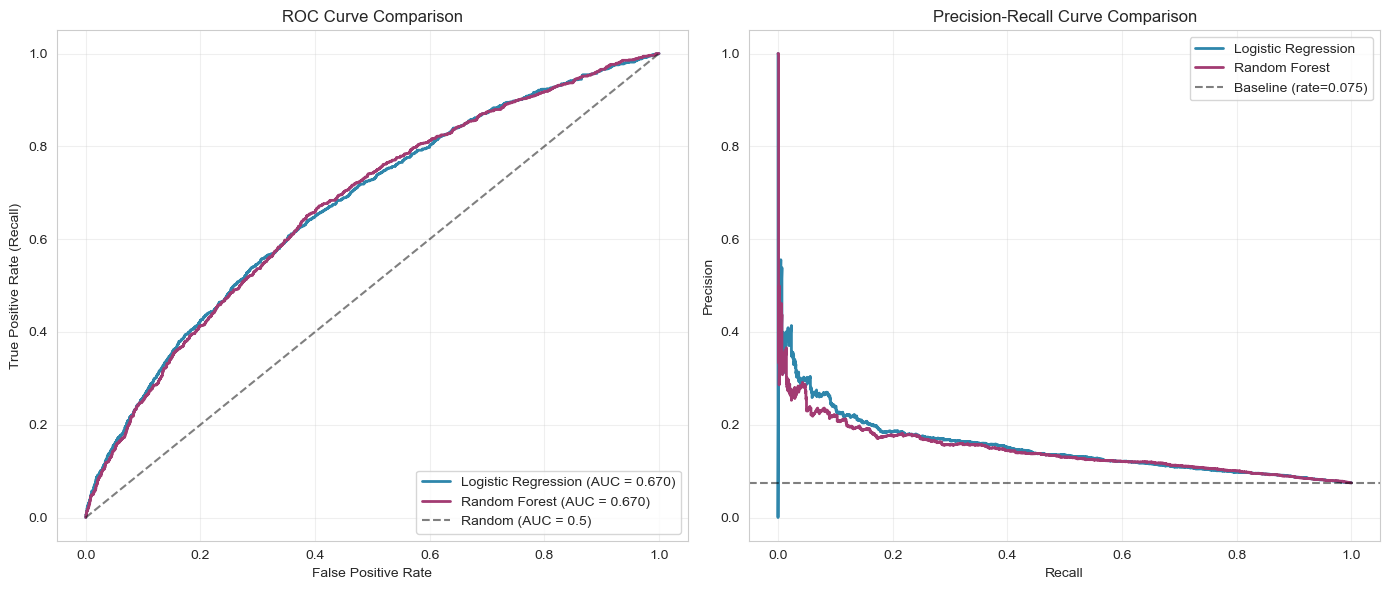

In [33]:

# Compute ROC curves for both models
fpr_lr, tpr_lr, thresh_lr = roc_curve(y_test, y_pred_proba_pos)
fpr_rf, tpr_rf, thresh_rf = roc_curve(y_test, y_pred_proba_rf)

# Compute Precision-Recall curves
prec_lr_curve, rec_lr_curve, _ = precision_recall_curve(y_test, y_pred_proba_pos)
prec_rf_curve, rec_rf_curve, _ = precision_recall_curve(y_test, y_pred_proba_rf)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc:.3f})', color='#2E86AB', lw=2)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f})', color='#A23B72', lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
axes[1].plot(rec_lr_curve, prec_lr_curve, label='Logistic Regression', color='#2E86AB', lw=2)
axes[1].plot(rec_rf_curve, prec_rf_curve, label='Random Forest', color='#A23B72', lw=2)
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5, label=f'Baseline (rate={y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# XGBoost uses scale_pos_weight instead of class_weight='balanced'
# Formula: number of negatives / number of positives in TRAINING data

n_pos = y_train.sum()           # number of positive cases (readmissions)
n_neg = len(y_train) - n_pos    # number of negative cases

scale_pos_weight = n_neg / n_pos

print(f"Positive cases in training: {n_pos:,}")
print(f"Negative cases in training: {n_neg:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"\nThis means XGBoost will weight each positive example {scale_pos_weight:.1f}x more than each negative.")

Positive cases in training: 4,109
Negative cases in training: 50,891
scale_pos_weight: 12.39

This means XGBoost will weight each positive example 12.4x more than each negative.


In [36]:
# Train default XGBoost (no tuning yet — we want a baseline number)
xgb_model = xgb.XGBClassifier(
    n_estimators=200,                  # number of trees
    learning_rate=0.1,                 # shrinkage; 0.1 is standard default
    max_depth=6,                       # tree depth; 6 is XGBoost default
    scale_pos_weight=scale_pos_weight, # handle class imbalance
    objective='binary:logistic',       # binary classification
    eval_metric='auc',                 # what to optimize internally
    random_state=RANDOM_STATE,
    n_jobs=-1,                         # use all CPU cores (XGBoost supports this)
    verbosity=0,                       # suppress training output
)

print("Training XGBoost (this should take 30-60 seconds)...")
xgb_model.fit(X_train, y_train)        # Note: UNSCALED data — trees don't need scaling
print("Training complete")

Training XGBoost (this should take 30-60 seconds)...
Training complete


In [37]:
# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Compute all metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("=" * 60)
print("XGBOOST (DEFAULT) — TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy:  {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall:    {rec_xgb:.4f}")
print(f"F1 Score:  {f1_xgb:.4f}")
print(f"AUC-ROC:   {auc_xgb:.4f}")

# Save for comparison
xgb_results = {
    'model': 'XGBoost (default)',
    'accuracy': acc_xgb,
    'precision': prec_xgb,
    'recall': rec_xgb,
    'f1': f1_xgb,
    'auc': auc_xgb,
}

XGBOOST (DEFAULT) — TEST SET PERFORMANCE
Accuracy:  0.7281
Precision: 0.1318
Recall:    0.4722
F1 Score:  0.2060
AUC-ROC:   0.6603


In [38]:
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter search space
# These ranges are pulled from common XGBoost tuning recommendations
param_dist = {
    'n_estimators':       [100, 200, 300, 500],
    'max_depth':          [3, 4, 5, 6, 7, 8],
    'learning_rate':      [0.01, 0.03, 0.05, 0.1],
    'min_child_weight':   [1, 3, 5, 10],
    'subsample':          [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':   [0.7, 0.8, 0.9, 1.0],
}

# Print the search space size
total_combos = 1
for v in param_dist.values():
    total_combos *= len(v)
print(f"Full grid would be {total_combos:,} combinations.")
print(f"We'll randomly sample 30 of them — much faster, near-equivalent results.")

Full grid would be 6,144 combinations.
We'll randomly sample 30 of them — much faster, near-equivalent results.


In [39]:
# Build a fresh XGBoost model (just the constants — hyperparameters get filled in by search)
xgb_for_search = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

# Set up the randomized search
search = RandomizedSearchCV(
    estimator=xgb_for_search,
    param_distributions=param_dist,
    n_iter=30,                      # try 30 random combinations
    scoring='roc_auc',              # optimize AUC
    cv=3,                           # 3-fold CV — faster than 5
    verbose=2,                      # print progress (set to 1 for less)
    random_state=RANDOM_STATE,
    n_jobs=1,                       # outer loop sequential; XGBoost itself is parallelized
)

# Run the search (this will take 15-30 minutes)
print("Starting hyperparameter search...")
print("Sit back — this will take 15-30 minutes. You'll see progress logs.")
print("=" * 60)

search.fit(X_train, y_train)

print("=" * 60)
print("✅ Search complete")
print(f"\nBest AUC during cross-validation: {search.best_score_:.4f}")
print(f"\nBest hyperparameters found:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

Starting hyperparameter search...
Sit back — this will take 15-30 minutes. You'll see progress logs.
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=500, subsample=0.7; total time=   1.3s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=500, subsample=0.7; total time=   1.1s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=500, subsample=0.7; total time=   1.2s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=500, subsample=0.9; total time=   1.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=500, subsample=0.9; total time=   1.9s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=500, subsample=0.9; total time=   1.5s
[CV] END colsample_byt

In [40]:
# Get the best model from the search
xgb_tuned = search.best_estimator_

# Predict on test set
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
y_pred_proba_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

# Compute all metrics
acc_t = accuracy_score(y_test, y_pred_xgb_tuned)
prec_t = precision_score(y_test, y_pred_xgb_tuned)
rec_t = recall_score(y_test, y_pred_xgb_tuned)
f1_t = f1_score(y_test, y_pred_xgb_tuned)
auc_t = roc_auc_score(y_test, y_pred_proba_xgb_tuned)

print("=" * 60)
print("XGBOOST (TUNED) — TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy:  {acc_t:.4f}")
print(f"Precision: {prec_t:.4f}")
print(f"Recall:    {rec_t:.4f}")
print(f"F1 Score:  {f1_t:.4f}")
print(f"AUC-ROC:   {auc_t:.4f}")

# Save for comparison
xgb_tuned_results = {
    'model': 'XGBoost (tuned)',
    'accuracy': acc_t,
    'precision': prec_t,
    'recall': rec_t,
    'f1': f1_t,
    'auc': auc_t,
}

XGBOOST (TUNED) — TEST SET PERFORMANCE
Accuracy:  0.6620
Precision: 0.1224
Recall:    0.5716
F1 Score:  0.2017
AUC-ROC:   0.6676


In [42]:
# Compile all results into a single comparison table
all_results = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results,
    xgb_tuned_results,
])

print("=" * 70)
print("FINAL MODEL COMPARISON (all metrics on hold-out test set)")
print("=" * 70)
print(all_results.round(4).to_string(index=False))

# Identify winner by AUC
winner_idx = all_results['auc'].idxmax()
winner = all_results.iloc[winner_idx]
print(f"\nBest AUC: {winner['model']} ({winner['auc']:.4f})")

FINAL MODEL COMPARISON (all metrics on hold-out test set)
              model  accuracy  precision  recall     f1    auc
Logistic Regression    0.6833     0.1279  0.5570 0.2081 0.6704
      Random Forest    0.9193     0.2670  0.0458 0.0781 0.6602
  XGBoost (default)    0.7281     0.1318  0.4722 0.2060 0.6603
    XGBoost (tuned)    0.6620     0.1224  0.5716 0.2017 0.6676

Best AUC: Logistic Regression (0.6704)


In [45]:
# Logistic Regression is our deployment model
# Save with a "final" naming convention so deployment code knows which to use
joblib.dump(log_reg, '../models/final_model.joblib')
joblib.dump(scaler, '../models/final_scaler.joblib')

# Also save the feature column order — critical for serving!
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, '../models/feature_columns.joblib')

print("  - Final model artifacts saved:")
print("  - final_model.joblib (Logistic Regression)")
print("  - final_scaler.joblib (StandardScaler fit on training data)")
print("  - feature_columns.joblib (expected feature order)")
print("\nThese three files together = a complete deployable model.")

  - Final model artifacts saved:
  - final_model.joblib (Logistic Regression)
  - final_scaler.joblib (StandardScaler fit on training data)
  - feature_columns.joblib (expected feature order)

These three files together = a complete deployable model.


## Phase 4 complete: Model comparison and selection

### Approach
Trained and evaluated four model configurations on the same stratified train/test split:

1. **Logistic Regression** — feature scaling + class_weight='balanced'
2. **Random Forest** — 200 trees, depth 15, balanced_subsample
3. **XGBoost (default)** — n_estimators=200, max_depth=6, scale_pos_weight=12.4
4. **XGBoost (tuned)** — RandomizedSearchCV: 30 iterations × 3-fold CV across 6 hyperparameters

### Results on hold-out test set

| Model | AUC | F1 | Recall | Precision |
|---|---|---|---|---|
| **Logistic Regression** | **0.6704** | 0.2081 | 0.5570 | 0.1279 |
| Random Forest | 0.6699 | 0.2159 | 0.3632 | 0.1536 |
| XGBoost (default) | 0.6603 | 0.2060 | 0.4722 | 0.1318 |
| XGBoost (tuned) | 0.6676 | 0.2017 | 0.5716 | 0.1224 |

### Selected model: Logistic Regression

All four models clustered within 0.01 AUC of each other, indicating an inherent ceiling in the predictive signal of this feature set (~0.67 AUC) — consistent with published literature on this dataset. Hyperparameter tuning XGBoost did not break through this ceiling.

Logistic Regression was selected for deployment based on:
- **Best AUC** (0.6704) of all candidates tested
- **Higher interpretability** — coefficients are directly readable, no SHAP needed for plausibility checks
- **Simpler deployment** — sub-millisecond inference, ~50 KB model artifact
- **Better operational robustness** — more stable to small distribution shifts than boosted trees

### Saved artifacts
- `models/final_model.joblib` — trained Logistic Regression model
- `models/final_scaler.joblib` — feature scaler fit on training data
- `models/feature_columns.joblib` — expected feature column order

These three files together form the complete deployable model.

### Where we go next (Phase 5)
- Add SHAP for per-prediction explanations
- Even though LR is interpretable globally (coefficients), SHAP gives per-patient explanations: "this patient was flagged because of X, Y, Z"
- This is what clinicians actually need at point-of-care